In [1]:
import pandas as pd

In [2]:
df= pd.read_csv('chhindwara_aqi_sample (1).csv')

In [3]:
df

,Date,City,AQI
0,2024-01-01,Chhindwara,98
1,2024-01-02,Chhindwara,102
2,2024-01-03,Chhindwara,105
3,2024-01-04,Chhindwara,95
4,2024-01-05,Chhindwara,93
5,2024-01-06,Chhindwara,97
6,2024-01-07,Chhindwara,100
7,2024-01-08,Chhindwara,99
8,2024-01-09,Chhindwara,101
9,2024-01-10,Chhindwara,96


In [4]:
df.rename(columns={'Date' : 'DateTime'}, inplace=True)

In [5]:
df

,DateTime,City,AQI
0,2024-01-01,Chhindwara,98
1,2024-01-02,Chhindwara,102
2,2024-01-03,Chhindwara,105
3,2024-01-04,Chhindwara,95
4,2024-01-05,Chhindwara,93
5,2024-01-06,Chhindwara,97
6,2024-01-07,Chhindwara,100
7,2024-01-08,Chhindwara,99
8,2024-01-09,Chhindwara,101
9,2024-01-10,Chhindwara,96


In [6]:
df_new = df.copy()

In [7]:
df

,DateTime,City,AQI
0,2024-01-01,Chhindwara,98
1,2024-01-02,Chhindwara,102
2,2024-01-03,Chhindwara,105
3,2024-01-04,Chhindwara,95
4,2024-01-05,Chhindwara,93
5,2024-01-06,Chhindwara,97
6,2024-01-07,Chhindwara,100
7,2024-01-08,Chhindwara,99
8,2024-01-09,Chhindwara,101
9,2024-01-10,Chhindwara,96


In [8]:
df_new.describe()

,AQI
count,10.000000
mean,98.600000
std,3.565265
min,93.000000
25%,96.250000
50%,98.500000
75%,100.750000
max,105.000000


In [9]:
df_new['DateTime'] = pd.to_datetime(df_new['DateTime'])
df_new['AQI_lag1'] = df_new['AQI'].shift(1)
df_new['AQI_lag2'] = df_new['AQI'].shift(2)

In [10]:
df_new

,DateTime,City,AQI,AQI_lag1,AQI_lag2
0,2024-01-01,Chhindwara,98,NaN,NaN
1,2024-01-02,Chhindwara,102,98.0,NaN
2,2024-01-03,Chhindwara,105,102.0,98.0
3,2024-01-04,Chhindwara,95,105.0,102.0
4,2024-01-05,Chhindwara,93,95.0,105.0
5,2024-01-06,Chhindwara,97,93.0,95.0
6,2024-01-07,Chhindwara,100,97.0,93.0
7,2024-01-08,Chhindwara,99,100.0,97.0
8,2024-01-09,Chhindwara,101,99.0,100.0
9,2024-01-10,Chhindwara,96,101.0,99.0


In [11]:
df_new = df_new.dropna()

In [12]:
df_new

,DateTime,City,AQI,AQI_lag1,AQI_lag2
2,2024-01-03,Chhindwara,105,102.0,98.0
3,2024-01-04,Chhindwara,95,105.0,102.0
4,2024-01-05,Chhindwara,93,95.0,105.0
5,2024-01-06,Chhindwara,97,93.0,95.0
6,2024-01-07,Chhindwara,100,97.0,93.0
7,2024-01-08,Chhindwara,99,100.0,97.0
8,2024-01-09,Chhindwara,101,99.0,100.0
9,2024-01-10,Chhindwara,96,101.0,99.0


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
# Calculating correlation matrix
corr_matrix = df_new.corr(numeric_only=True)
corr_matrix = df_new[['AQI' , 'AQI_lag1' , 'AQI_lag2']].corr()
print(corr_matrix)

               AQI  AQI_lag1  AQI_lag2
AQI       1.000000  0.212098 -0.513830
AQI_lag1  0.212098  1.000000  0.240577
AQI_lag2 -0.513830  0.240577  1.000000


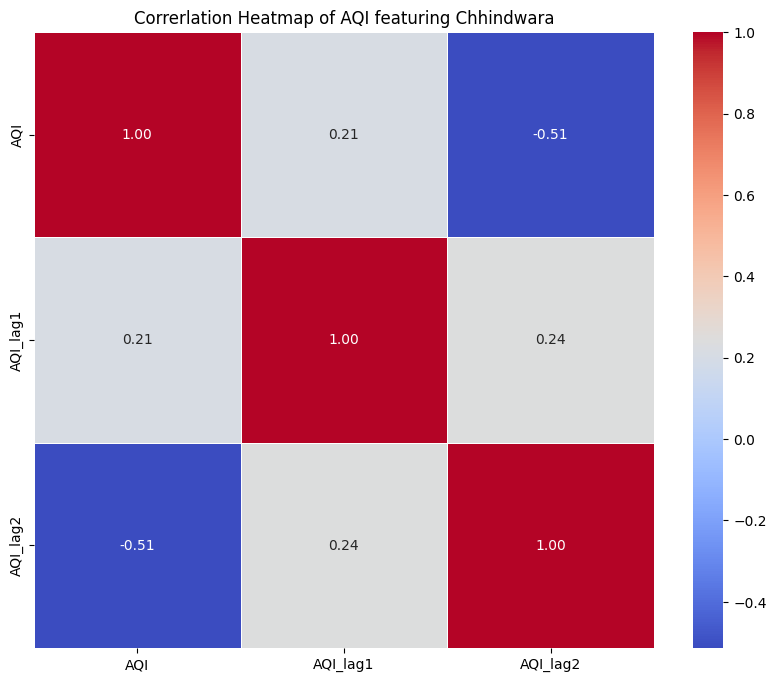

In [15]:
# Plotting
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths= 0.5)
plt.title("Correrlation Heatmap of AQI featuring Chhindwara")
plt.show()

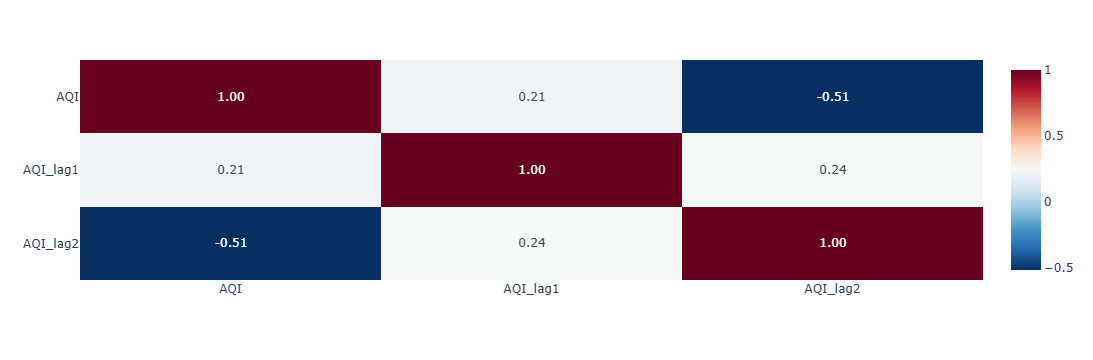

In [16]:
import plotly.express as px
fig= px.imshow(corr_matrix, text_auto=".2f", color_continuous_scale='RdBu_r', aspect="auto")
fig.show()

In [17]:
features = ['AQI', 'AQI_lag1', 'AQI_lag2']
print("Summart Statistics")
print(df_new[features].describe())

Summart Statistics
              AQI    AQI_lag1    AQI_lag2
count    8.000000    8.000000    8.000000
mean    98.250000   99.000000   98.625000
std      3.807887    3.891382    3.814914
min     93.000000   93.000000   93.000000
25%     95.750000   96.500000   96.500000
50%     98.000000   99.500000   98.500000
75%    100.250000  101.250000  100.500000
max    105.000000  105.000000  105.000000


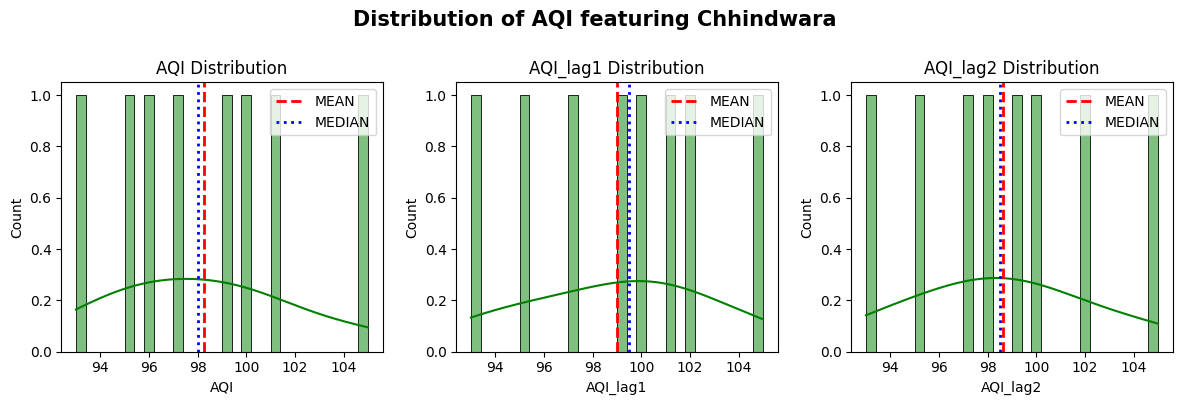

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
features= ['AQI', 'AQI_lag1', 'AQI_lag2']
plt.figure(figsize=(12,4))

for i, feature in enumerate(features):
    plt.subplot(1,3,i+1)
    sns.histplot(df_new[feature], kde=True, bins=30, color='green')
    #adding vertical lines for mean and median
    mean_value= df_new[feature].mean()
    median_value= df_new[feature].median()
    plt.axvline(mean_value, color='red', linestyle='--', linewidth=2, label='MEAN')
    plt.axvline(median_value, color='blue', linestyle=':', linewidth=2, label='MEDIAN')
    plt.title(f"{feature} Distribution")
    plt.xlabel(feature)
    plt.legend()
    
#adding title
plt.suptitle("Distribution of AQI featuring Chhindwara", fontsize=15, fontweight="bold", y=1)
plt.tight_layout()
plt.show()

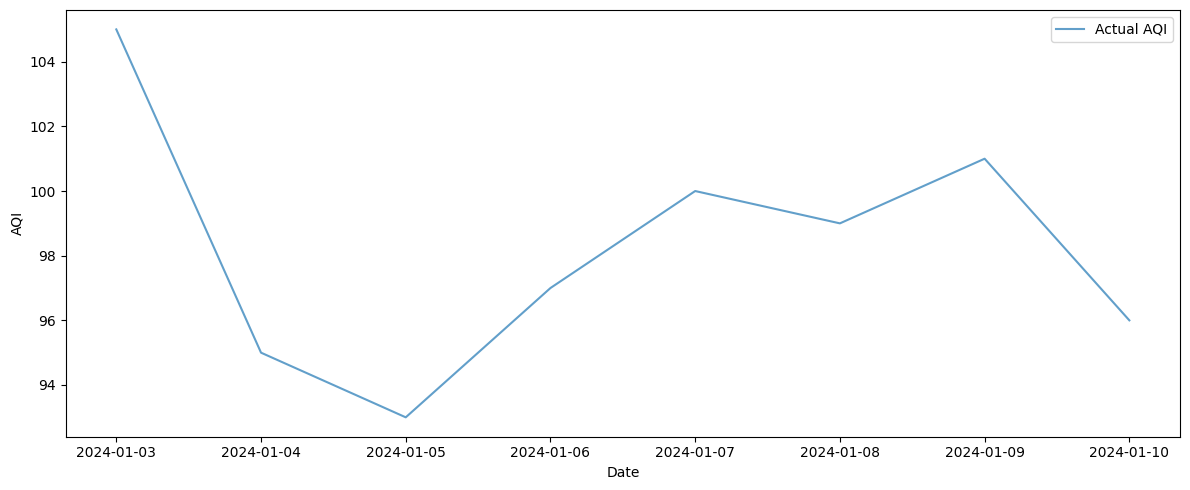

In [19]:
plt.figure(figsize=(12,5))
plt.plot(df_new['DateTime'], df_new['AQI'], label='Actual AQI', alpha=0.7)
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
pollutants = pd.read_excel("pm2.5_pm10.xlsx")

In [21]:
pollutants

,Unnamed: 0,DateTime,PM10 (µg/m3),PM2.5 (µg/m3),NOX (ppb),SO2 (µg/m3),NH3 (µg/m3)
0,1,2025-06-27 17:15:00,38,31,11.3,7.5,12.8
1,2,2025-06-27 17:30:00,38,31,8.5,7.5,12.7
2,3,2025-06-27 17:45:00,38,31,9.1,7.5,12.6
3,4,2025-06-27 18:00:00,38,31,13.7,7.5,12.5
4,5,2025-06-27 18:15:00,35,29,18.9,7.5,12.4
5,6,2025-06-27 18:30:00,35,29,17.4,7.5,12.3
6,7,2025-06-27 18:45:00,35,29,13.1,7.5,12.2
7,8,2025-06-27 19:00:00,35,29,12.6,7.5,12.1
8,9,2025-06-27 19:15:00,38,31,13.7,7.3,11.9
9,10,2025-06-27 19:30:00,39,32,16.9,7.1,11.7


In [22]:
#showing variation in values between 3pm and 11.45pm
pollutants_df= pollutants.iloc[[0,1,7,8,9,12,15,16,20,23,26]]
pollutants_df

,Unnamed: 0,DateTime,PM10 (µg/m3),PM2.5 (µg/m3),NOX (ppb),SO2 (µg/m3),NH3 (µg/m3)
0,1,2025-06-27 17:15:00,38,31,11.3,7.5,12.8
1,2,2025-06-27 17:30:00,38,31,8.5,7.5,12.7
7,8,2025-06-27 19:00:00,35,29,12.6,7.5,12.1
8,9,2025-06-27 19:15:00,38,31,13.7,7.3,11.9
9,10,2025-06-27 19:30:00,39,32,16.9,7.1,11.7
12,13,2025-06-27 20:15:00,43,35,13.4,7.0,11.3
15,16,2025-06-27 21:00:00,29,19,16.6,7.0,11.1
16,17,2025-06-27 21:15:00,33,22,12.8,7.0,11.1
20,21,2025-06-27 22:15:00,31,20,9.7,7.0,11.4
23,24,2025-06-27 23:00:00,30,20,7.0,7.0,11.6


In [23]:
print(pollutants_df.columns)

Index(['Unnamed: 0', 'DateTime', 'PM10 (µg/m3)', 'PM2.5 (µg/m3)', 'NOX (ppb)',
       'SO2 (µg/m3)', 'NH3 (µg/m3)'],
      dtype='object')


In [24]:
pollutants_df= pollutants_df.reset_index(drop=True)
pollutants_df

,Unnamed: 0,DateTime,PM10 (µg/m3),PM2.5 (µg/m3),NOX (ppb),SO2 (µg/m3),NH3 (µg/m3)
0,1,2025-06-27 17:15:00,38,31,11.3,7.5,12.8
1,2,2025-06-27 17:30:00,38,31,8.5,7.5,12.7
2,8,2025-06-27 19:00:00,35,29,12.6,7.5,12.1
3,9,2025-06-27 19:15:00,38,31,13.7,7.3,11.9
4,10,2025-06-27 19:30:00,39,32,16.9,7.1,11.7
5,13,2025-06-27 20:15:00,43,35,13.4,7.0,11.3
6,16,2025-06-27 21:00:00,29,19,16.6,7.0,11.1
7,17,2025-06-27 21:15:00,33,22,12.8,7.0,11.1
8,21,2025-06-27 22:15:00,31,20,9.7,7.0,11.4
9,24,2025-06-27 23:00:00,30,20,7.0,7.0,11.6


In [25]:
pollutants_df= pollutants_df.drop(pollutants_df.columns[0], axis=1)
pollutants_df

,DateTime,PM10 (µg/m3),PM2.5 (µg/m3),NOX (ppb),SO2 (µg/m3),NH3 (µg/m3)
0,2025-06-27 17:15:00,38,31,11.3,7.5,12.8
1,2025-06-27 17:30:00,38,31,8.5,7.5,12.7
2,2025-06-27 19:00:00,35,29,12.6,7.5,12.1
3,2025-06-27 19:15:00,38,31,13.7,7.3,11.9
4,2025-06-27 19:30:00,39,32,16.9,7.1,11.7
5,2025-06-27 20:15:00,43,35,13.4,7.0,11.3
6,2025-06-27 21:00:00,29,19,16.6,7.0,11.1
7,2025-06-27 21:15:00,33,22,12.8,7.0,11.1
8,2025-06-27 22:15:00,31,20,9.7,7.0,11.4
9,2025-06-27 23:00:00,30,20,7.0,7.0,11.6


In [26]:
pollutants_df= pollutants_df.drop(pollutants_df.columns[0], axis=1)
pollutants_df

,PM10 (µg/m3),PM2.5 (µg/m3),NOX (ppb),SO2 (µg/m3),NH3 (µg/m3)
0,38,31,11.3,7.5,12.8
1,38,31,8.5,7.5,12.7
2,35,29,12.6,7.5,12.1
3,38,31,13.7,7.3,11.9
4,39,32,16.9,7.1,11.7
5,43,35,13.4,7.0,11.3
6,29,19,16.6,7.0,11.1
7,33,22,12.8,7.0,11.1
8,31,20,9.7,7.0,11.4
9,30,20,7.0,7.0,11.6


In [27]:
pollutants_df= pollutants_df.drop(pollutants_df.columns[0], axis=1)
pollutants_df

,PM2.5 (µg/m3),NOX (ppb),SO2 (µg/m3),NH3 (µg/m3)
0,31,11.3,7.5,12.8
1,31,8.5,7.5,12.7
2,29,12.6,7.5,12.1
3,31,13.7,7.3,11.9
4,32,16.9,7.1,11.7
5,35,13.4,7.0,11.3
6,19,16.6,7.0,11.1
7,22,12.8,7.0,11.1
8,20,9.7,7.0,11.4
9,20,7.0,7.0,11.6


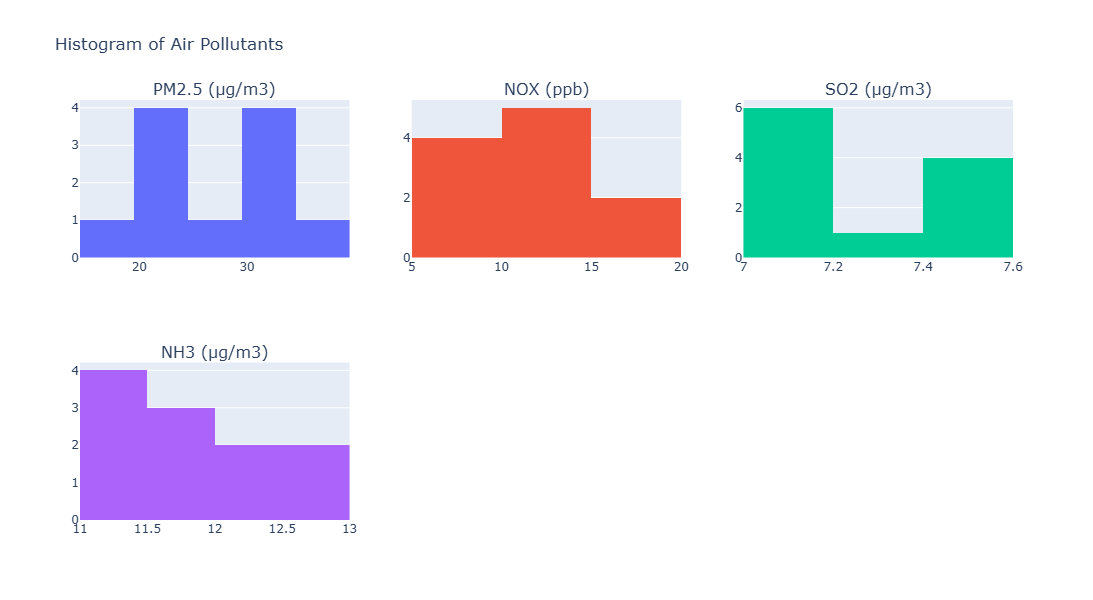

In [28]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.express as px

# Create subplots for each pollutant
chart = make_subplots(rows=2, cols=3, subplot_titles=pollutants_df.columns)

positions = [(1,1), (1,2), (1,3), (2,1), (2,2)]

# Add a histogram for each column
for i, col in enumerate(pollutants_df.columns):
    row, col_pos = positions[i]
    chart.add_trace(
        go.Histogram(x=pollutants_df[col], name=col),
        row=row, col=col_pos
    )

# Update layout
chart.update_layout(
    title_text='Histogram of Air Pollutants',
    height=600,
    width=1000,
    showlegend=False
)

chart.show()

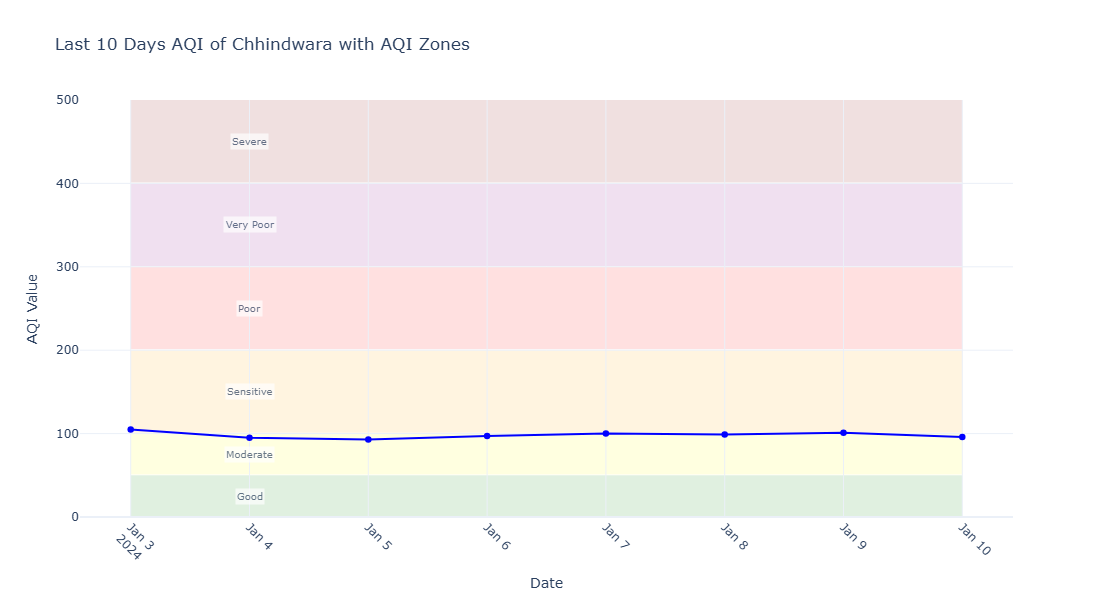

In [29]:
import plotly.graph_objects as go
import pandas as pd

real = df_new[['DateTime', 'AQI']].tail(25)

# Defining AQI zones
aqi_zones = [
    (0, 50, 'green', 'Good'),
    (51, 100, 'yellow', 'Moderate'),
    (101, 200, 'orange', 'Sensitive'),
    (201, 300, 'red', 'Poor'),
    (301, 400, 'purple', 'Very Poor'),
    (401, 500, 'maroon', 'Severe')
]

# Creating figure
fig = go.Figure()

for low, high, color, label in aqi_zones:
    fig.add_shape(type="rect",x0=real['DateTime'].min(), x1=real['DateTime'].max(), y0=low, y1=high, fillcolor=color, opacity=0.12,line=dict(width=0),
                  layer="below")
    fig.add_annotation(x=real['DateTime'].iloc[1],y=(low + high) / 2,text=label,showarrow=False,font=dict(size=10),bgcolor="white",opacity=0.7)

# Add AQI line chart
fig.add_trace(go.Scatter(
    x=real['DateTime'],
    y=real['AQI'],
    mode='lines+markers',
    name='Actual AQI',
    line=dict(color='blue'),
    marker=dict(size=6.5)
))

# Update layout
fig.update_layout(
    title='Last 10 Days AQI of Chhindwara with AQI Zones',
    xaxis_title='Date',
    yaxis_title='AQI Value',
    xaxis=dict(tickangle=45),
    template='plotly_white',
    height=600
)

fig.show()